In [1]:
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = f"{analysis_directory.name}/counts.zarr"
repack_store(
    f"{dataset}/data.zarr",
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=f"{analysis_directory.name}/analysis.zarr",
    nthreads=4,
    default_assay="RNA",
)
hvg_ref = ds.mark_hvgs(
    top_n=2000,
    show_plot=False,
    label="trajectory_hvgs",
)
normalized = ds.run_normalization(features=hvg_ref)
reduction = ds.run_pca(normalized, dims=15)
ann_index = ds.build_ann_index(reduction)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)
all_features = ds.resolve_features("RNA", "all_features")

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

...

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [2]:
multi_sink = ds.run_pseudotime_scoring(
    graph,
    source_sink_key="clusters",
    sources=["Ductal"],
    sinks=["Alpha", "Beta", "Delta"],
    label="multi_sink_pseudotime",
)

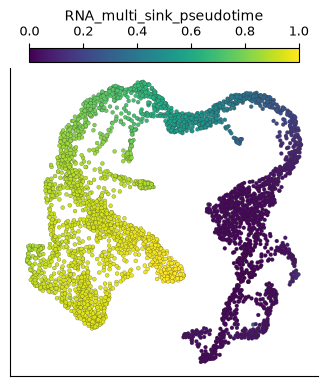

In [3]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=multi_sink.pseudotime_key,
    subset_by=multi_sink.validity_key,
)

In [4]:
beta_sink = ds.run_pseudotime_scoring(
    graph,
    source_sink_key="clusters",
    sources=["Ductal"],
    sinks=["Beta"],
    label="beta_sink_pseudotime",
)

In [5]:
boundary_results = {
    "Alpha, Beta, and Delta sinks": multi_sink,
    "Beta sink": beta_sink,
}
selected_cells = int(ds.cells.fetch_all("I").sum())
coverage = pd.DataFrame(
    {
        name: {
            "valid cells": int(
                ds.cells.fetch_all(result.validity_key).sum()
            ),
            "valid fraction": float(
                ds.cells.fetch_all(result.validity_key).sum()
                / selected_cells
            ),
        }
        for name, result in boundary_results.items()
    }
).T
coverage

,valid cells,valid fraction
"Alpha, Beta, and Delta sinks",3696.0,1.0
Beta sink,3696.0,1.0


In [6]:
multi_valid = ds.cells.fetch_all(multi_sink.validity_key).astype(bool)
beta_valid = ds.cells.fetch_all(beta_sink.validity_key).astype(bool)
shared_valid = multi_valid & beta_valid
if int(shared_valid.sum()) < 2:
    raise RuntimeError(
        "Boundary comparison needs at least two jointly valid cells"
    )

multi_values = ds.cells.fetch_all(multi_sink.pseudotime_key)
beta_values = ds.cells.fetch_all(beta_sink.pseudotime_key)
rank_agreement = pd.Series(
    multi_values[shared_valid]
).corr(
    pd.Series(beta_values[shared_valid]),
    method="spearman",
)
pd.Series(
    {
        "jointly valid cells": int(shared_valid.sum()),
        "Spearman rank agreement": rank_agreement,
    }
)

jointly valid cells        3696.00000
Spearman rank agreement       0.99273
dtype: float64

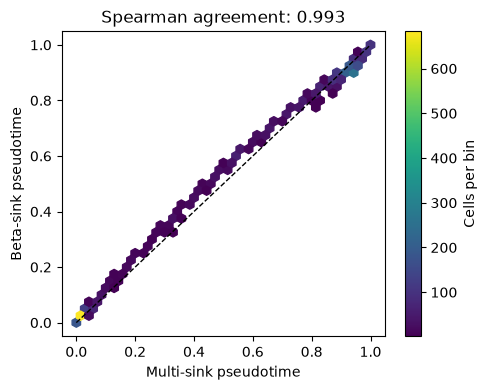

In [7]:
figure, axis = plt.subplots(figsize=(5, 4))
density = axis.hexbin(
    multi_values[shared_valid],
    beta_values[shared_valid],
    gridsize=35,
    mincnt=1,
    cmap="viridis",
)
comparison_min = min(
    multi_values[shared_valid].min(),
    beta_values[shared_valid].min(),
)
comparison_max = max(
    multi_values[shared_valid].max(),
    beta_values[shared_valid].max(),
)
axis.plot(
    [comparison_min, comparison_max],
    [comparison_min, comparison_max],
    color="black",
    linestyle="--",
    linewidth=1,
)
axis.set(
    xlabel="Multi-sink pseudotime",
    ylabel="Beta-sink pseudotime",
    title=f"Spearman agreement: {rank_agreement:.3f}",
)
figure.colorbar(density, ax=axis, label="Cells per bin")
figure.tight_layout()
plt.show()

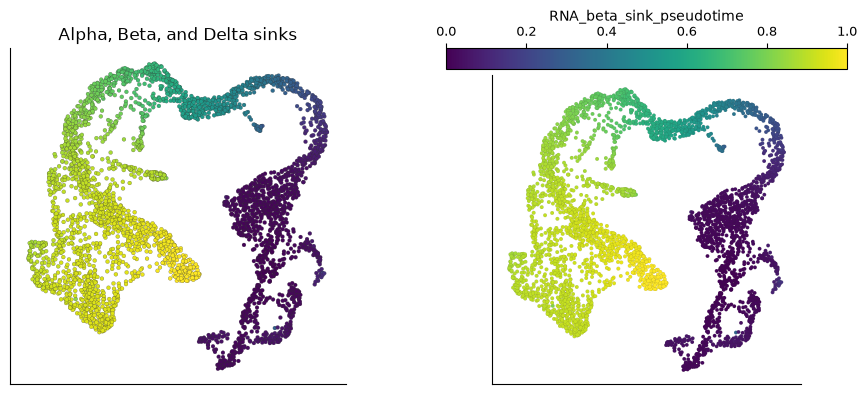

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for index, (axis, (title, result)) in enumerate(
    zip(axes, boundary_results.items(), strict=True)
):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=result.pseudotime_key,
        subset_by=result.validity_key,
        show_legend=index == 1,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure

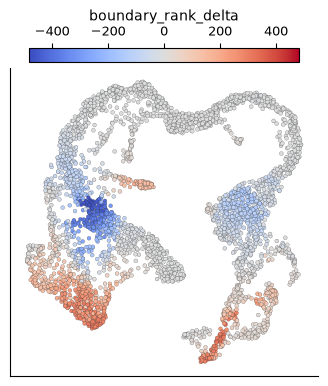

In [9]:
selected = ds.cells.fetch_all("I").astype(bool)
rank_delta = np.full(multi_values.shape[0], np.nan, dtype=float)
rank_delta[shared_valid] = (
    pd.Series(multi_values[shared_valid]).rank(method="average")
    - pd.Series(beta_values[shared_valid]).rank(method="average")
).to_numpy()
ds.cells.insert(
    "boundary_rank_delta",
    rank_delta[selected],
    key="I",
    overwrite=True,
)
ds.cells.insert(
    "boundary_shared_valid",
    shared_valid[selected],
    fill_value=False,
    key="I",
    overwrite=True,
)
rank_limit = float(np.nanmax(np.abs(rank_delta[shared_valid])))
if rank_limit == 0.0:
    rank_limit = 1.0
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="boundary_rank_delta",
    subset_by="boundary_shared_valid",
    color_scale=splt.ColorScale(
        cmap="coolwarm",
        vmin=-rank_limit,
        vmax=rank_limit,
        vcenter=0,
    ),
)

In [10]:
population_summary = pd.DataFrame(
    {
        "population": ds.cells.fetch_all("clusters"),
        "multi-sink pseudotime": np.where(
            multi_valid,
            multi_values,
            np.nan,
        ),
        "Beta-sink pseudotime": np.where(
            beta_valid,
            beta_values,
            np.nan,
        ),
    }
).groupby("population").agg(["count", "median"])
population_summary

multi-sink pseudotime           Beta-sink pseudotime          
                              count    median                count    median
population                                                                  
Alpha                           481  0.942188                  481  0.911882
Beta                            591  0.956189                  591  0.948270
Delta                            70  0.890034                   70  0.864803
Ductal                          916  0.014796                  916  0.017274
Epsilon                         142  0.901968                  142  0.888607
Ngn3 high EP                    642  0.484579                  642  0.539231
Ngn3 low EP                     262  0.033477                  262  0.040278
Pre-endocrine                   592  0.838772                  592  0.852911

In [11]:
markers = ds.run_pseudotime_marker_search(
    features=all_features,
    cell_key=multi_sink.validity_key,
    pseudotime_key=multi_sink.pseudotime_key,
)

(
    markers.table.loc[
        markers.table["p_value_adjusted"].notna(),
        ["feature_name", "r_value", "p_value", "p_value_adjusted"],
    ]
    .assign(abs_r_value=lambda frame: frame["r_value"].abs())
    .sort_values("abs_r_value", ascending=False)
    .drop(columns="abs_r_value")
    .head(10)
)

Finding correlated features: 2 / 2 complete

,feature_name,r_value,p_value,p_value_adjusted
24581,Rpl13,-0.829222,0.0,0.0
22385,Rps19,-0.822204,0.0,0.0
18864,Spp1,-0.820563,0.0,0.0
16254,Rps8,-0.817266,0.0,0.0
19815,Rpl32,-0.794270,0.0,0.0
26498,Rps4x,-0.794137,0.0,0.0
431,Dbi,-0.787537,0.0,0.0
13425,Rpl12,-0.769970,0.0,0.0
10164,Rps2,-0.755999,0.0,0.0
10232,Rpl10a,-0.754087,0.0,0.0


In [12]:
markers.table[["p_value", "p_value_adjusted"]].isna().sum()

p_value             14177
p_value_adjusted    14177
dtype: int64

In [13]:
module_results = {}
module_rows = []
for name, n_clusters in {"coarse": 6, "fine": 12}.items():
    result = ds.run_pseudotime_aggregation(
        features=all_features,
        cell_key=multi_sink.validity_key,
        pseudotime_key=multi_sink.pseudotime_key,
        cluster_label=f"trajectory_modules_{name}",
        n_clusters=n_clusters,
        window_size=200,
        chunk_size=100,
    )
    module_results[name] = result
    assignments = pd.Series(result.feature_clusters)
    module_sizes = assignments[assignments != -1].value_counts()
    module_rows.append(
        {
            "setting": name,
            "requested modules": n_clusters,
            "assigned features": int(module_sizes.sum()),
            "observed modules": int(len(module_sizes)),
            "smallest module": int(module_sizes.min()),
            "largest module": int(module_sizes.max()),
        }
    )
pd.DataFrame(module_rows).set_index("setting")

Binning over cell-ordering: 2 / 2 complete

Fitting feature KNN: 1 / 1 complete

Identifying feature neighbors: 1 / 1 complete

Sorting clusters: 1 / 1 complete

Binning over cell-ordering: 2 / 2 complete

Fitting feature KNN: 1 / 1 complete

Identifying feature neighbors: 1 / 1 complete

Sorting clusters: 1 / 1 complete

,requested modules,assigned features,observed modules,smallest module,largest module
setting,,,,,
coarse,6,12455,6,953,2871
fine,12,12455,12,407,1880


In [14]:
coarse_modules = module_results["coarse"]
fine_modules = module_results["fine"]
module_features = ds.RNA.feats.to_pandas_dataframe(
    [
        "names",
        coarse_modules.cluster_key,
        fine_modules.cluster_key,
    ]
)
assigned_both = module_features[
    (module_features[coarse_modules.cluster_key] != -1)
    & (module_features[fine_modules.cluster_key] != -1)
]
pd.crosstab(
    assigned_both[coarse_modules.cluster_key],
    assigned_both[fine_modules.cluster_key],
    normalize="index",
).round(2)

trajectory_modules_fine,1,2,3,4,5,6,7,8,9,10,11,12
trajectory_modules_coarse,,,,,,,,,,,,
1,0.61,0.25,0.00,0.14,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0
2,0.00,0.00,0.00,0.00,1.0,0.00,0.00,0.00,0.0,0.00,0.00,0.0
3,0.00,0.00,0.00,0.00,0.0,0.54,0.46,0.00,0.0,0.00,0.00,0.0
4,0.00,0.00,0.57,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.43,0.0
5,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.41,0.0,0.59,0.00,0.0
6,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.7,0.00,0.00,0.3


coarse modules (trajectory_modules_coarse)


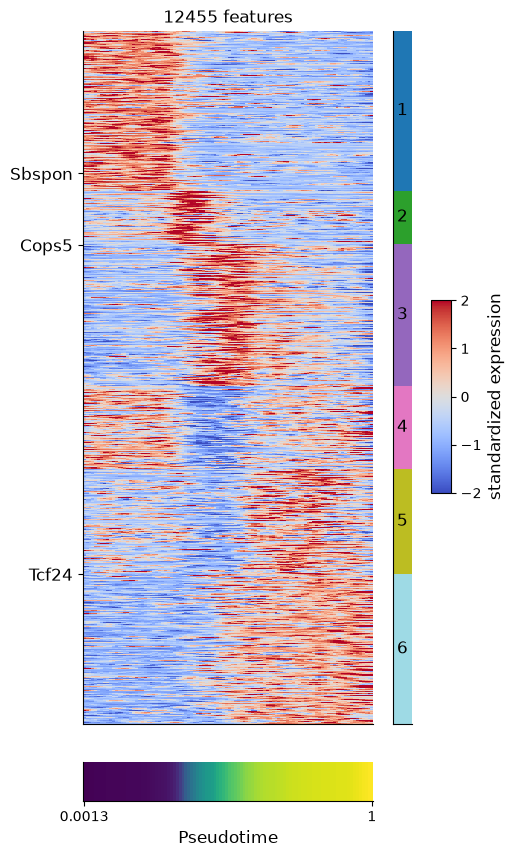

fine modules (trajectory_modules_fine)


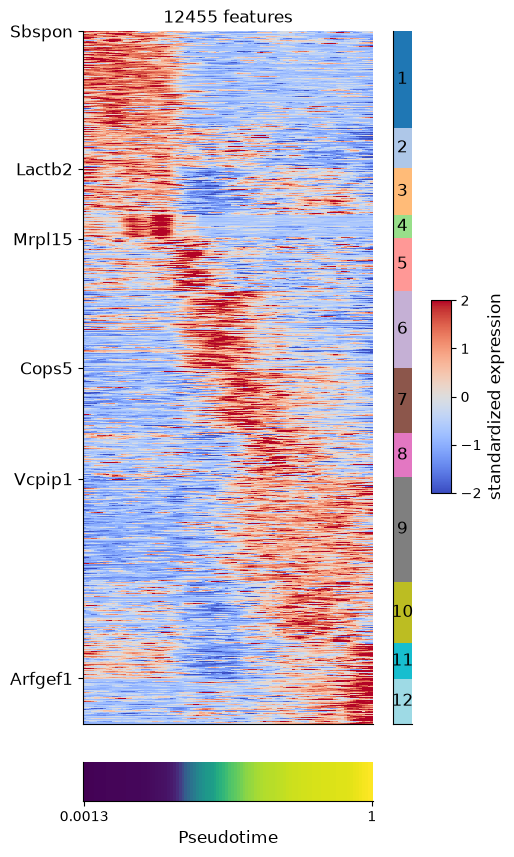

In [15]:
for name, modules in module_results.items():
    assigned = module_features[
        module_features[modules.cluster_key] != -1
    ]
    representatives = (
        assigned.groupby(modules.cluster_key, sort=True)["names"]
        .first()
    )
    labels = representatives.iloc[::2].tolist()
    print(f"{name} modules ({modules.cluster_key})")
    ds.plots.pseudotime_heatmap(
        cell_key=modules.cell_key,
        features=modules.feature_selection,
        feature_cluster_key=modules.cluster_key,
        pseudotime_key=modules.pseudotime_key,
        show_features=labels,
    )

In [16]:
modules = fine_modules
assigned = module_features[
    module_features[modules.cluster_key] != -1
]
cluster_marker_ref = ds.run_marker_search(
    group_key="clusters",
    cell_key="I",
    features=all_features,
)
beta_markers = set(
    ds.get_markers(
        marker=cluster_marker_ref,
        cell_key="I",
        group_key="clusters",
        group_id="Beta",
    ).feature_name
)
module_overlap = (
    assigned.groupby(modules.cluster_key)["names"]
    .apply(lambda names: len(set(names) & beta_markers))
    .sort_values(ascending=False)
)
module_overlap.head()

Finding markers: 2 / 2 complete

trajectory_modules_fine
12    67
9     32
10    10
11     5
7      2
Name: names, dtype: int64

In [17]:
fate = ds.run_fate_mapping(
    graph,
    cell_key="I",
    subset_cell_key=multi_sink.validity_key,
    pseudotime_key=multi_sink.pseudotime_key,
    sink_key="clusters",
    sinks=["Alpha", "Beta", "Delta"],
)

valid_probabilities = fate.values[fate.valid]
simplex_error = float(
    np.max(np.abs(valid_probabilities.sum(axis=1) - 1.0))
)
simplex_error

1.1920928955078125e-07

In [18]:
selected_labels = ds.cells.fetch(
    fate.sink_key,
    key=fate.result_cell_key,
)
terminal_checks = []
for index, sink in enumerate(fate.sink_labels):
    rows = (selected_labels == sink) & fate.valid
    terminal_checks.append(
        {
            "sink": sink,
            "cells": int(rows.sum()),
            "minimum own probability": float(
                fate.values[rows, index].min()
            ),
        }
    )
pd.DataFrame(terminal_checks)

,sink,cells,minimum own probability
0,Alpha,481,1.0
1,Beta,591,1.0
2,Delta,70,1.0


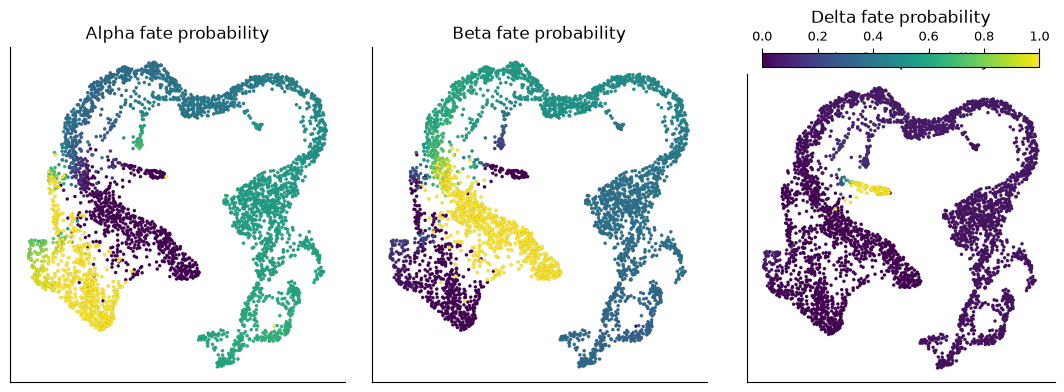

In [19]:
figure, axes = plt.subplots(1, 3, figsize=(11, 4))
probability_scale = splt.ColorScale(vmin=0, vmax=1)
for index, (axis, sink, fate_key) in enumerate(
    zip(axes, fate.sink_labels, fate.fate_keys, strict=True)
):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=fate_key,
        subset_by=fate.validity_key,
        color_scale=probability_scale,
        sort_values=True,
        show_legend=index == 2,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(f"{sink} fate probability")
for colorbar_axis in set(figure.axes) - set(axes):
    colorbar_axis.set_title(f"{fate.sink_labels[-1]} fate probability")
    colorbar_axis.set_xlabel("")
    colorbar_axis.set_ylabel("")
figure.tight_layout()
figure

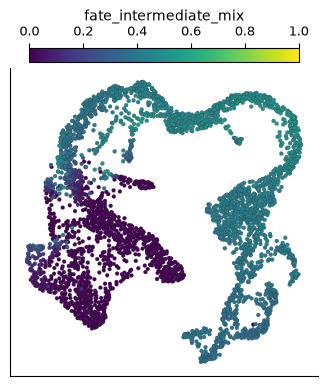

In [20]:
mix_values = np.full(len(fate.valid), np.nan, dtype=float)
mix_values[fate.valid] = 1.0 - fate.values[fate.valid].max(axis=1)
ds.cells.insert(
    "fate_intermediate_mix",
    mix_values,
    key=fate.result_cell_key,
    overwrite=True,
)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="fate_intermediate_mix",
    subset_by=fate.validity_key,
    color_scale=splt.ColorScale(vmin=0, vmax=1),
    sort_values=True,
)